In [92]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt


%config InlineBackend.figure_format='retina'
xr.set_options(display_style="text")


In [93]:
# Load mean sea surface temperature dataset
ds_ref = xr.open_dataset("../../data/sst.oisst.mon.ltm.1991-2020.nc", engine="netcdf4")
# ds = xr.open_dataset("../../data/sst.day.mean.ltm.nc", engine="netcdf4") # 365, 720, 1440
# ds = xr.open_dataset("../../data/sst.mnmean.nc", engine="netcdf4")
# ds = xr.open_dataset("../../data/sst.oisst.mon.ltm.1991-2020.nc", engine="netcdf4") # 12,180,360
ds = xr.open_dataset("../../data/sst.wkmean.1990-present.nc", engine="netcdf4") # 1727 but no countries

# xarray's HTML representation
ds_copy = ds.copy(deep=True)

/var/folders/k8/8bd2c6nd31s1yp4rsc4gj7340000gn/T/ipykernel_99770/1112961928.py:2: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates prior reform date (1582-10-15). To silence this warning specify 'use_cftime=True'.
  ds_ref = xr.open_dataset("../../data/sst.oisst.mon.ltm.1991-2020.nc", engine="netcdf4")
/var/folders/k8/8bd2c6nd31s1yp4rsc4gj7340000gn/T/ipykernel_99770/1112961928.py:2: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates prior reform date (1582-10-15). To silence this warning specify 'use_cftime=True'.
  ds_ref = xr.open_dataset("../../data/sst.oisst.mon.ltm.1991-2020.nc", engine="netcdf4")


In [94]:
indices = np.argwhere(np.isnan(ds_ref.sst[0].data))

In [95]:
for (idx_y, idx_x) in indices:
    ds.sst[dict(lat=-idx_y, lon=idx_x)] = np.nan

In [96]:
ds['sst']
min_coords = [5.5 , 55.5] #latitute, longitude
max_coords = [35.5,  85.5]

In [98]:
ds.sst

<xarray.DataArray 'sst' (time: 1727, lat: 180, lon: 360)> Size: 448MB
[111909600 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 14kB 1989-12-31 1990-01-07 ... 2023-01-29
  * lat      (lat) float32 720B 89.5 88.5 87.5 86.5 ... -86.5 -87.5 -88.5 -89.5
  * lon      (lon) float32 1kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
Attributes:
    long_name:             Weekly Mean of Sea Surface Temperature
    unpacked_valid_range:  [-5. 40.]
    actual_range:          [-1.8  36.16]
    units:                 degC
    precision:             2
    var_desc:              Sea Surface Temperature
    dataset:               NOAA Optimum Interpolation (OI) SST V2
    level_desc:            Surface
    statistic:             Weekly Mean
    parent_stat:           Individual obs
    standard_name:         sea_surface_temperature
    valid_range:           [-500 4000]

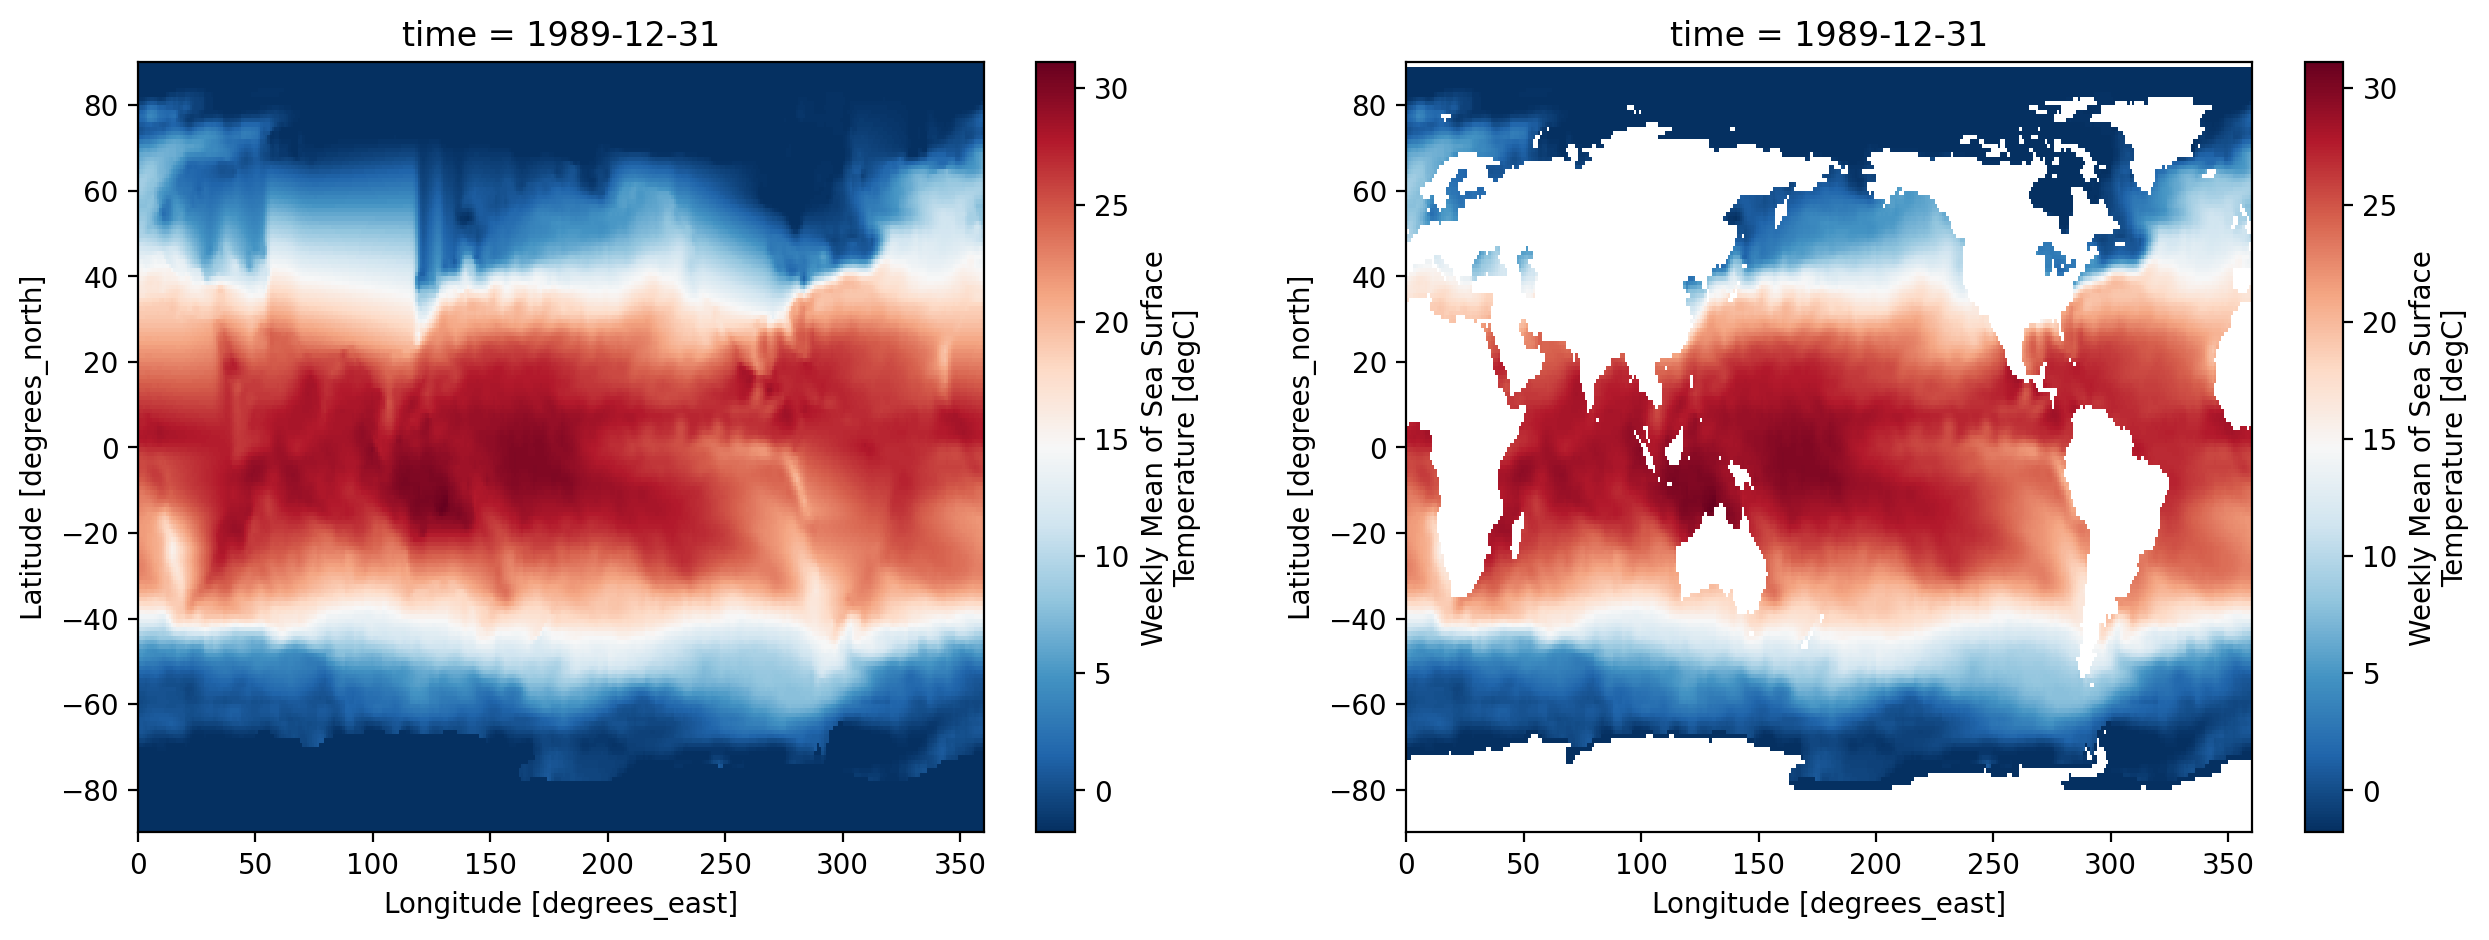

In [107]:
plt.figure(figsize=(15,5))
plt.subplot(121)
ds_copy.sst[0].plot(center=False, cmap='RdBu_r')
plt.subplot(122)
ds.sst[0].plot(center=False, cmap='RdBu_r')

In [120]:
min_temp, max_temp = ds.sst.attrs['actual_range']
print(min_temp, max_temp)
da = ds.sst

-1.8 36.16


In [110]:
print(min_coords, max_coords)

[5.5, 55.5] [35.5, 85.5]


In [111]:
min_lat_idx = int(np.where(da.lat.data==max_coords[0])[0])
max_lat_idx = int(np.where(da.lat.data==min_coords[0])[0])

min_lon_idx = int(np.where(da.lon.data==min_coords[1])[0])
max_lon_idx = int(np.where(da.lon.data==max_coords[1])[0])

print(min_lat_idx, max_lat_idx)
print(min_lon_idx, max_lon_idx)

54 84
55 85


/var/folders/k8/8bd2c6nd31s1yp4rsc4gj7340000gn/T/ipykernel_99770/1888061029.py:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  min_lat_idx = int(np.where(da.lat.data==max_coords[0])[0])
/var/folders/k8/8bd2c6nd31s1yp4rsc4gj7340000gn/T/ipykernel_99770/1888061029.py:2: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  max_lat_idx = int(np.where(da.lat.data==min_coords[0])[0])
/var/folders/k8/8bd2c6nd31s1yp4rsc4gj7340000gn/T/ipykernel_99770/1888061029.py:4: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this opera

In [112]:
da.data.shape

data_sq = da.data[:, min_lat_idx:max_lat_idx+1, min_lon_idx:max_lon_idx+1]

print("min/max lat/lon values", min_lat_idx, max_lat_idx, min_lon_idx, max_lon_idx)
print("data shape: ", data_sq.shape) # time, lat, lon

min/max lat/lon values 54 84 55 85
data shape:  (1727, 31, 31)


In [113]:
sst_sq = ds.sst[:,min_lat_idx:max_lat_idx+1, min_lon_idx:max_lon_idx+1]

print(sst_sq.shape)

mean_temp = sst_sq.mean(dim="time")
seasonal_mean = sst_sq.groupby("time.season").mean()
seasonal_mean = seasonal_mean.sel(season=["DJF", "MAM", "JJA", "SON"])

std_temp = sst_sq.std(dim="time")
seasonal_ssd = sst_sq.groupby("time.season").std()
seasonal_ssd = seasonal_ssd.sel(season=["DJF", "MAM", "JJA", "SON"])

(1727, 31, 31)


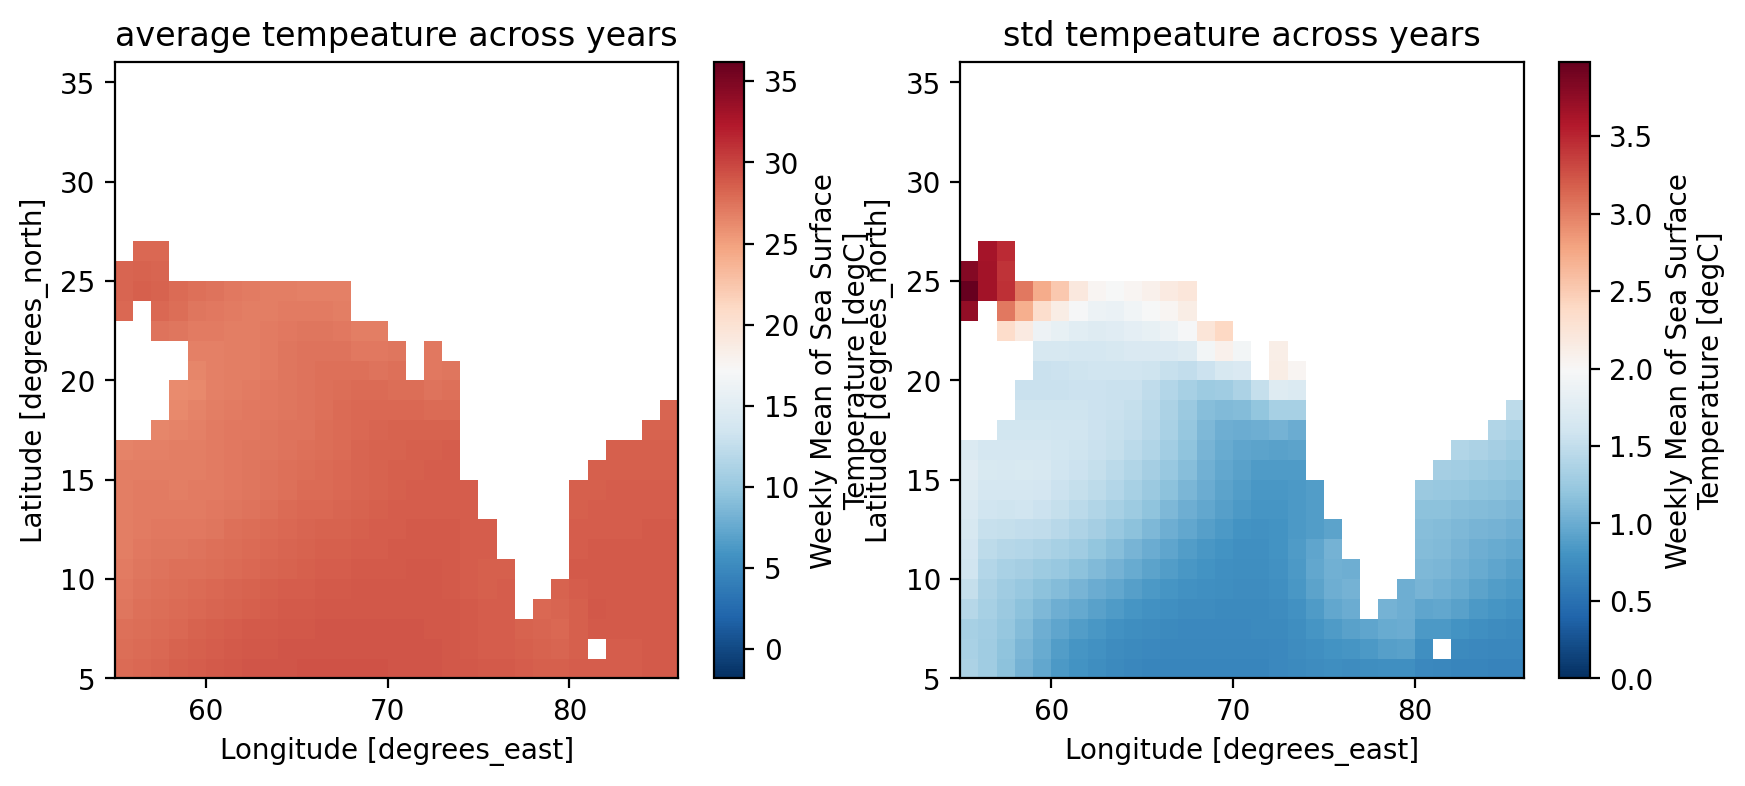

mean tempeature across years grouped by seasons


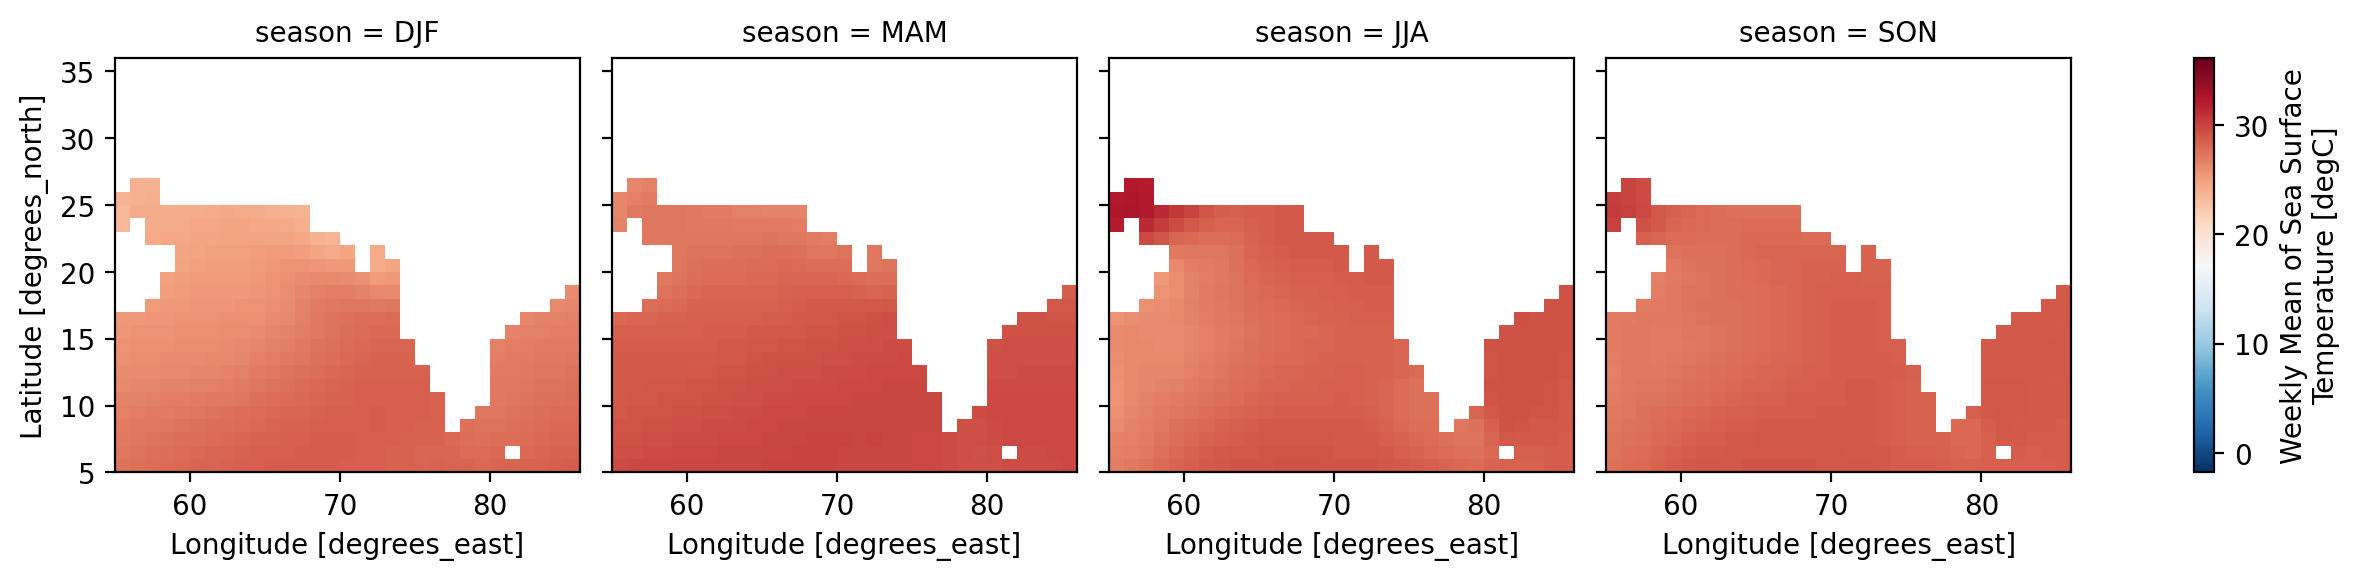

std tempeature across years grouped by seasons


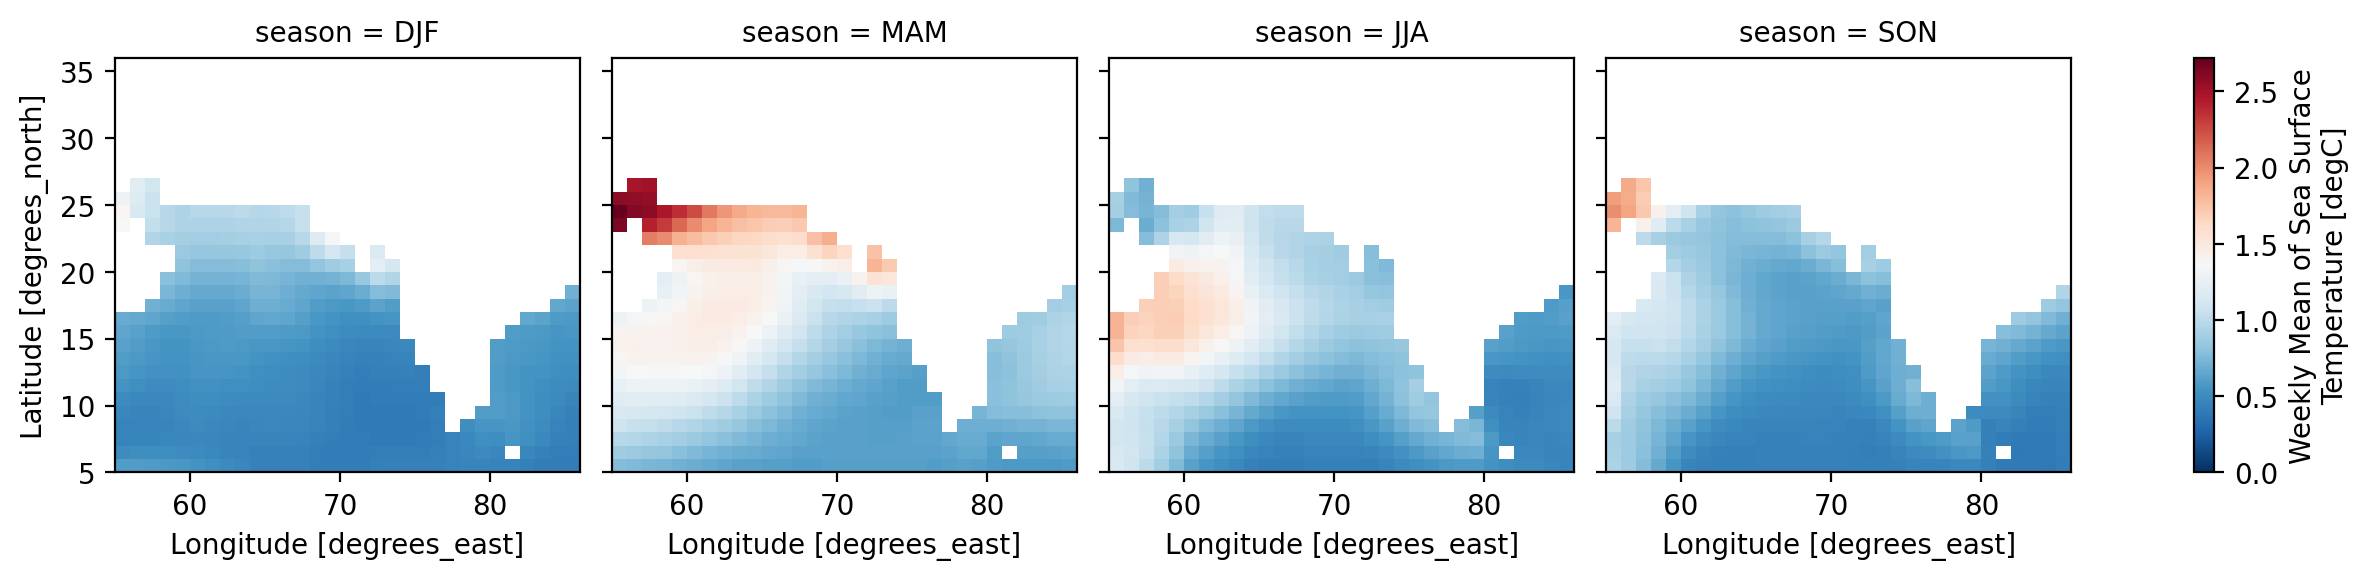

In [124]:
plt.figure(figsize=(10,4))
plt.subplot(121)
mean_temp.plot(cmap='RdBu_r', vmin=min_temp, vmax=max_temp, center=False)
plt.title('average tempeature across years')

plt.subplot(122)
std_temp.plot(cmap='RdBu_r', vmin=0, vmax=std_temp.max())
plt.title('std tempeature across years')
plt.show()

print('mean tempeature across years grouped by seasons')
seasonal_mean.plot(col='season',cmap='RdBu_r', vmin=min_temp, vmax=max_temp, center=False)
plt.show()

print('std tempeature across years grouped by seasons')
seasonal_ssd.plot(col='season',cmap='RdBu_r', vmin=0, vmax=seasonal_ssd.max())
plt.show()


In [76]:

print(sst_sq.shape)

yearly_mean = sst_sq.groupby("time.year").mean()
yearly_std = sst_sq.groupby("time.year").std()

(1727, 31, 31)
